# CellTypist vs CyteType agreement with cxg labels

Upstream steps (CellTypist, clustering, CyteType, CyteOnto) are run by [`run_pipeline.py`](run_pipeline.py). This notebook loads the cached annotated h5ad and CyteOnto CSV, then compares cxg (`cell_type`) and CyteType against CellTypist `predicted_labels` as the CyteOnto author reference.

In [79]:
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns

from cyteonto import attach_cytescores_to_obs
from cytetype_runner.utils import confidence_by_cluster
from shared.repo import REPO_ROOT

## Config
Get metadata for dataset to select the appropriate CellTypist model

In [80]:
from metadata import sample_row_for_srx
from metadata.config import MetadataConfig

SRX = "SRX12366723"

cfg = MetadataConfig(
    sampleParquetPath=REPO_ROOT / "data/scbasecount/2026-01-12/metadata/GeneFull/Homo_sapiens/scbasecount_2026-01-12_metadata_GeneFull_Homo_sapiens_sample_metadata.parquet",
    obsParquetPath=REPO_ROOT / "data/scbasecount/2026-01-12/metadata/GeneFull/Homo_sapiens/scbasecount_2026-01-12_metadata_GeneFull_Homo_sapiens_obs_metadata.parquet",
)

sample = sample_row_for_srx(SRX, cfg)
sample

entrez_id                                                            16543594
srx_accession                                                     SRX12366723
file_path                   gs://arc-institute-virtual-cell-atlas/scbaseco...
obs_count                                                                4032
lib_prep                                                         10x_Genomics
tech_10x                                                          3_prime_gex
cell_prep                                                         single_cell
organism                                                         Homo sapiens
tissue                                                                   lung
tissue_ontology_term_id                                        UBERON:0002048
disease                                                        lung neoplasms
disease_ontology_term_id                                        MONDO:0021117
perturbation                                                    

In [81]:
CELLTYPIST_COL = "predicted_labels"
CXG_COL = "cell_type"
CYTETYPE_COL = "cytetype_annotation_leiden_merged"
AUTHOR_COL = CELLTYPIST_COL

OUTPUT_ROOT = REPO_ROOT / "output" / "celltypist_vs_cxg"
DATA_DIR = OUTPUT_ROOT / "data"
FIGS_DIR = REPO_ROOT / "writeups" / "celltypist_vs_cxg" / ".figs"

annotated_path = DATA_DIR / f"{SRX}_cytetype_annotated.h5ad"
cyteonto_csv_path = OUTPUT_ROOT / "cyteonto_results" / f"{SRX}_cyteonto.csv"

FIGS_DIR.mkdir(parents=True, exist_ok=True)

In [82]:
missing = [p for p in (annotated_path, cyteonto_csv_path) if not p.is_file()]
if missing:
    missing_str = "\n".join(f"  - {p}" for p in missing)
    raise FileNotFoundError(
        f"Cached outputs not found. Run run_pipeline.py first:\n"
        f"  uv run python writeups/celltypist_vs_cxg/run_pipeline.py --srx {SRX}\n"
        f"Missing:\n{missing_str}"
    )

adata = sc.read_h5ad(annotated_path)
cyteonto_df = pd.read_csv(cyteonto_csv_path)
cyteonto_df.head()

,run_id,algorithm,pair_index,author_label,algorithm_label,author_ontology_id,author_embedding_similarity,algorithm_ontology_id,algorithm_embedding_similarity,cytescore_similarity,similarity_method
0,run-641d8659-03d7-4a60-bda0-9b2427f71898,cxg,0,SC & Eosinophil,B cell,CL:0000771,0.8914,CL:0000945,0.8685,0.0968,cytescore
1,run-641d8659-03d7-4a60-bda0-9b2427f71898,cxg,1,SC & Eosinophil,B cell,CL:0000771,0.8914,CL:0000945,0.8685,0.0968,cytescore
2,run-641d8659-03d7-4a60-bda0-9b2427f71898,cxg,2,CD8m T,B cell,CL:0000940,0.8388,CL:0000945,0.8685,0.0815,cytescore
3,run-641d8659-03d7-4a60-bda0-9b2427f71898,cxg,3,SC & Eosinophil,B cell,CL:0000771,0.8914,CL:0000945,0.8685,0.0968,cytescore
4,run-641d8659-03d7-4a60-bda0-9b2427f71898,cxg,4,SC & Eosinophil,plasma cell,CL:0000771,0.8914,CL:0000786,0.9133,0.1214,cytescore


In [83]:
_algorithm_cols = {"cxg": CXG_COL, "cytetype": CYTETYPE_COL}

cyteonto_df = cyteonto_df.drop_duplicates(
    ["algorithm", "author_label", "algorithm_label"]
).reset_index(drop=True)

cyteonto_df["count"] = 0
for _algorithm, _algorithm_col in _algorithm_cols.items():
    _obs_pairs = (
        adata.obs[AUTHOR_COL].astype(str)
        + "|"
        + adata.obs[_algorithm_col].astype(str).replace("nan", "")
    ).value_counts()
    _mask = cyteonto_df["algorithm"] == _algorithm
    _pairs = (
        cyteonto_df.loc[_mask, "author_label"].astype(str)
        + "|"
        + cyteonto_df.loc[_mask, "algorithm_label"].fillna("").astype(str)
    )
    cyteonto_df.loc[_mask, "count"] = _pairs.map(_obs_pairs).fillna(0).astype(int)

cyteonto_df[["algorithm", "author_label", "algorithm_label", "cytescore_similarity", "count"]].head()

,algorithm,author_label,algorithm_label,cytescore_similarity,count
0,cxg,SC & Eosinophil,B cell,0.0968,1652
1,cxg,CD8m T,B cell,0.0815,188
2,cxg,SC & Eosinophil,plasma cell,0.1214,163
3,cxg,RBC,"CD4-positive, alpha-beta T cell",0.1040,3
4,cxg,NK,B cell,0.0979,228


In [94]:
cyteonto_df["weighted_cytescore_similarity"] = (
    cyteonto_df["cytescore_similarity"] * cyteonto_df["count"]
)

(
    cyteonto_df
    .groupby(["algorithm"])[[
        "cytescore_similarity", "weighted_cytescore_similarity"
    ]]
    .mean()
)

,cytescore_similarity,weighted_cytescore_similarity
algorithm,,
cxg,0.157856,7.839463
cytetype,0.085693,7.747056


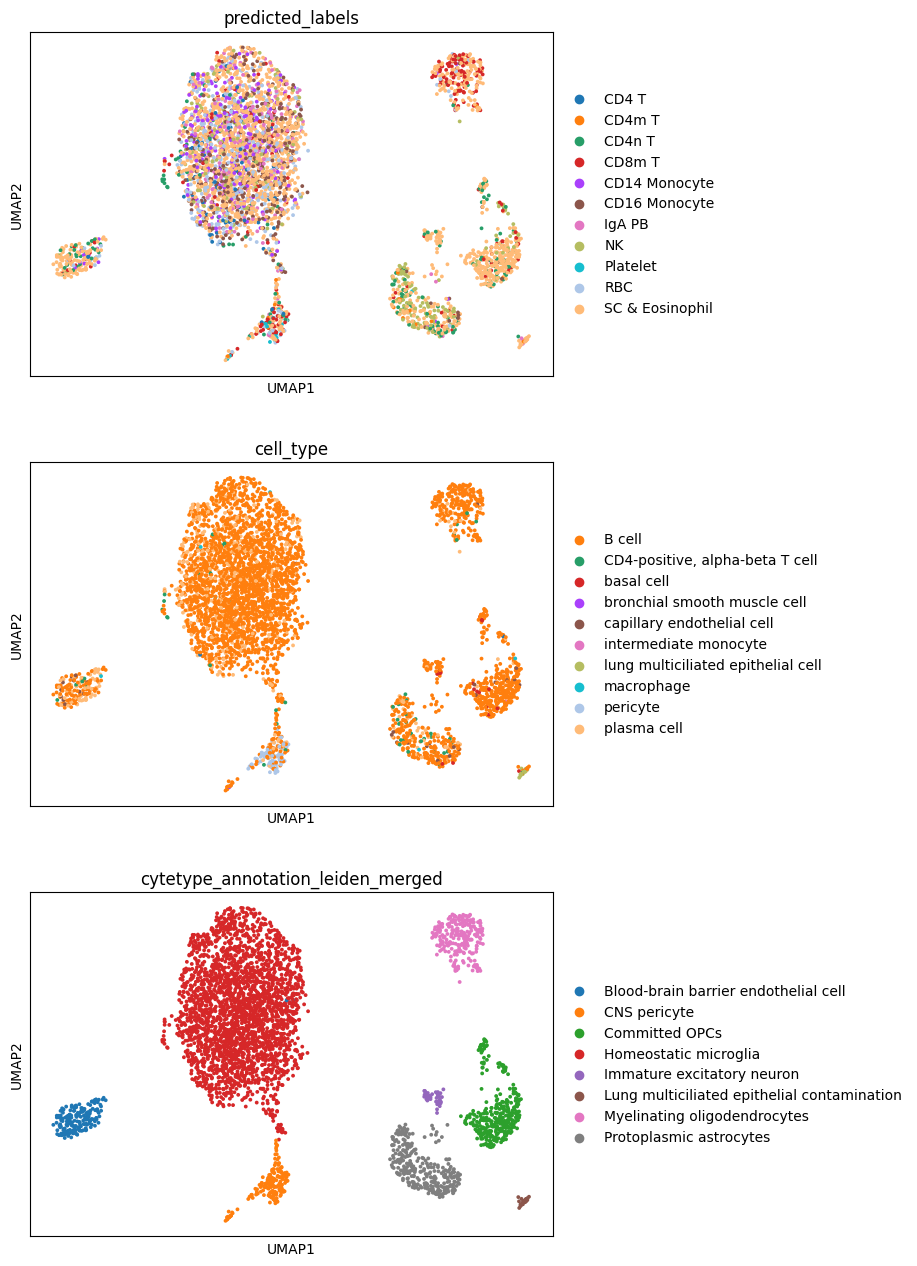

In [99]:
sc.pl.umap(adata, color=["predicted_labels", CXG_COL, CYTETYPE_COL], ncols=1)

## Analysis: cxg vs cytetype agreement with CellTypist

In [6]:
obs = adata.obs.copy()
obs = attach_cytescores_to_obs(
    obs,
    cyteonto_df,
    author_col=AUTHOR_COL,
    algorithm_col=CXG_COL,
    algorithm="cxg",
    out_col="cytescore_cxg",
)
obs = attach_cytescores_to_obs(
    obs,
    cyteonto_df,
    author_col=AUTHOR_COL,
    algorithm_col=CYTETYPE_COL,
    algorithm="cytetype",
    out_col="cytescore_cytetype",
)
obs = obs.dropna(subset=["cytescore_cxg", "cytescore_cytetype"])
obs[[AUTHOR_COL, CXG_COL, CYTETYPE_COL, "cytescore_cxg", "cytescore_cytetype"]].head()

,predicted_labels,cell_type,cytetype_annotation_leiden_merged,cytescore_cxg,cytescore_cytetype
AAACCCACATAGGCGA,SC & Eosinophil,B cell,Protoplasmic astrocytes,0.0968,0.1329
AAACCCAGTGACTAAA,SC & Eosinophil,B cell,Committed OPCs,0.0968,0.0862
AAACCCATCATTTCGT,CD8m T,B cell,Myelinating oligodendrocytes,0.0815,0.0684
AAACCCATCCACCCTA,SC & Eosinophil,B cell,Homeostatic microglia,0.0968,0.1255
AAACGAAAGCACGGAT,SC & Eosinophil,B cell,Committed OPCs,0.0968,0.0862


In [7]:
summary = (
    obs.groupby(AUTHOR_COL, observed=True)
    .agg(
        n_cells=(AUTHOR_COL, "size"),
        mean_cytescore_cxg=("cytescore_cxg", "mean"),
        mean_cytescore_cytetype=("cytescore_cytetype", "mean"),
    )
    .assign(
        delta_cxg_minus_cytetype=lambda df: (
            df["mean_cytescore_cxg"] - df["mean_cytescore_cytetype"]
        )
    )
    .sort_values("n_cells", ascending=False)
)
summary

,n_cells,mean_cytescore_cxg,mean_cytescore_cytetype,delta_cxg_minus_cytetype
predicted_labels,,,,
SC & Eosinophil,1922,0.099566,0.115305,-0.015739
RBC,420,0.069606,0.070236,-0.000630
CD16 Monocyte,384,0.114624,0.206755,-0.092131
NK,286,0.108155,0.057007,0.051149
CD8m T,231,0.080794,0.070068,0.010726
CD14 Monocyte,231,0.189308,0.247708,-0.058400
IgA PB,207,0.172778,0.055581,0.117197
CD4n T,177,0.162285,0.065033,0.097251
CD4 T,74,0.200700,0.100809,0.099891


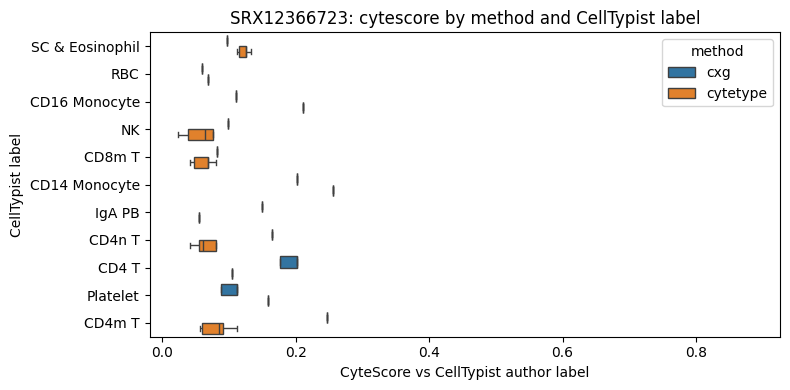

In [8]:
long = obs.melt(
    id_vars=[AUTHOR_COL],
    value_vars=["cytescore_cxg", "cytescore_cytetype"],
    var_name="method",
    value_name="cytescore_similarity",
)
long["method"] = long["method"].map(
    {
        "cytescore_cxg": "cxg",
        "cytescore_cytetype": "cytetype",
    }
)
order = summary.index.tolist()

fig, ax = plt.subplots(figsize=(8, max(4, len(order) * 0.25)))
sns.boxplot(
    data=long,
    x="cytescore_similarity",
    y=AUTHOR_COL,
    hue="method",
    order=order,
    fliersize=0,
    ax=ax,
)
ax.set_xlabel("CyteScore vs CellTypist author label")
ax.set_ylabel("CellTypist label")
ax.set_title(f"{SRX}: cytescore by method and CellTypist label")
fig.tight_layout()
fig.savefig(FIGS_DIR / f"cytescore_by_method_{SRX}.png", dpi=150, bbox_inches="tight")
plt.show()

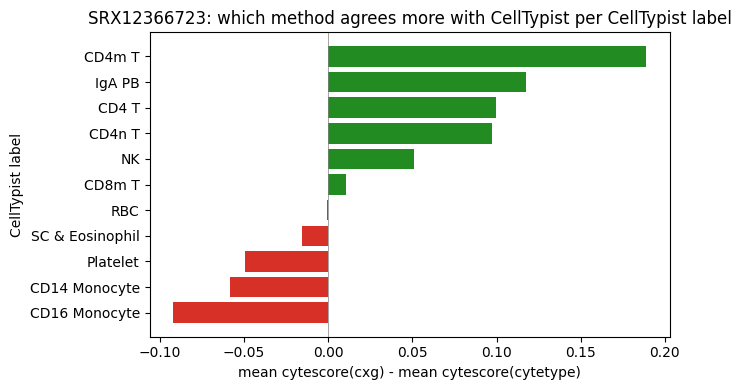

In [9]:
delta = summary["delta_cxg_minus_cytetype"].sort_values()

fig, ax = plt.subplots(figsize=(7, max(4, len(delta) * 0.25)))
colors = ["#228B22" if v > 0 else "#d73027" for v in delta]
ax.barh(delta.index, delta.values, color=colors)
ax.axvline(0, color="grey", linewidth=0.5)
ax.set_xlabel("mean cytescore(cxg) - mean cytescore(cytetype)")
ax.set_ylabel("CellTypist label")
ax.set_title(f"{SRX}: which method agrees more with CellTypist per CellTypist label")
fig.tight_layout()
fig.savefig(FIGS_DIR / f"cytescore_delta_{SRX}.png", dpi=150, bbox_inches="tight")
plt.show()

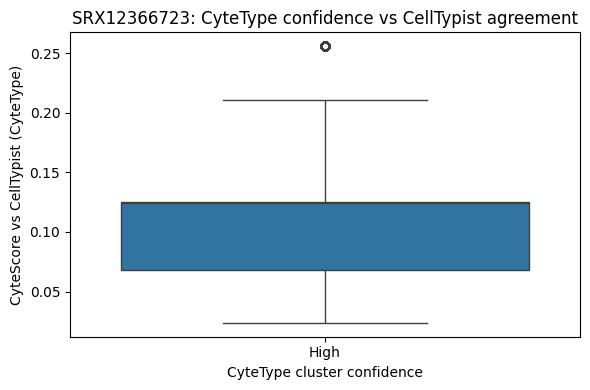

In [10]:
confidence_map = confidence_by_cluster(adata)
obs["cytetype_confidence"] = obs["leiden_merged"].astype(str).map(confidence_map)

conf_order = ["Low", "Moderate", "High"]
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(
    data=obs,
    x="cytetype_confidence",
    y="cytescore_cytetype",
    order=[c for c in conf_order if c in obs["cytetype_confidence"].unique()],
    ax=ax,
)
ax.set_xlabel("CyteType cluster confidence")
ax.set_ylabel("CyteScore vs CellTypist (CyteType)")
ax.set_title(f"{SRX}: CyteType confidence vs CellTypist agreement")
fig.tight_layout()
fig.savefig(FIGS_DIR / f"cytescore_vs_confidence_{SRX}.png", dpi=150, bbox_inches="tight")
plt.show()